# --- 1. Imports ---

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import kagglehub

# --- 2. Load Data ---

In [5]:
path = kagglehub.dataset_download("whenamancodes/fraud-detection")
df = pd.read_csv(f"{path}/creditcard.csv")
df.tail(2)

100%|██████████| 66.0M/66.0M [00:01<00:00, 55.8MB/s]

Extracting files...


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.0,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.0,0


# --- 3. Basic EDA ---

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


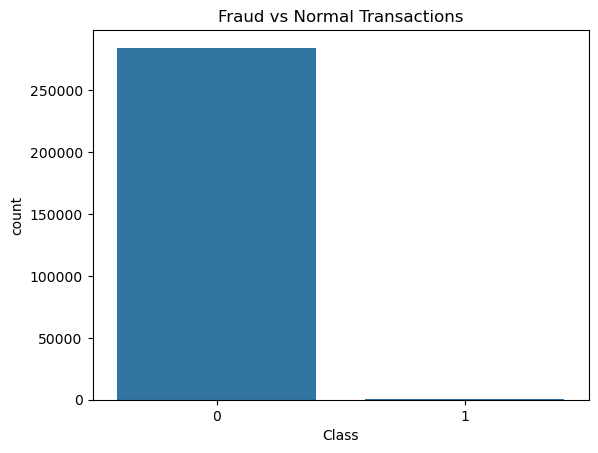

In [6]:
print(df.shape)
print(df['Class'].value_counts())

# Fraud vs Non-Fraud
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

# --- 4. Check Imbalance ---

In [7]:
fraud_ratio = df['Class'].value_counts(normalize=True)
print(fraud_ratio)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


# --- 5. Feature Scaling ---

In [9]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

In [10]:
# Optional: drop Time if not needed
df = df.drop(columns=['Time'])

# --- 6. Train-Test Split ---

In [11]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 7. Handle Imbalance (SMOTE) ---

In [12]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts())
print("After:", pd.Series(y_train_res).value_counts())

Before: Class
0    227451
1       394
Name: count, dtype: int64
After: Class
0    227451
1    227451
Name: count, dtype: int64


# --- 8. Baseline Model (Logistic Regression) ---

In [13]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

# --- 9. Random Forest Model ---

In [14]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# --- 10. Evaluation ---

## --- 10-A. Classification Report ---

In [16]:
print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("Random Forest:\n", classification_report(y_test, y_pred_rf))

Logistic Regression:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

Random Forest:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



## --- 10-B. Confusion Matrix ---

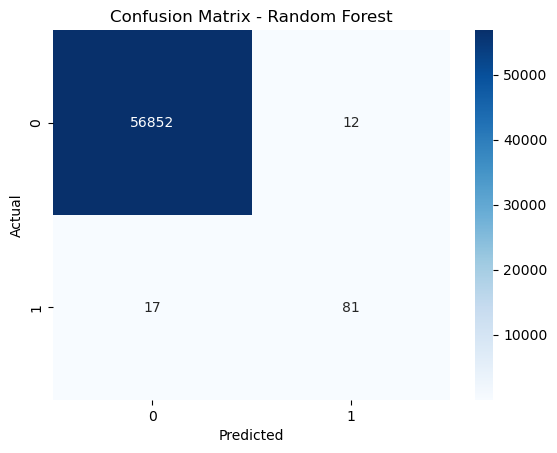

In [15]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## --- 10-C. ROC-AUC ---

In [17]:
roc_lr = roc_auc_score(y_test, y_proba_lr)
roc_rf = roc_auc_score(y_test, y_proba_rf)

print("ROC-AUC LR:", roc_lr)
print("ROC-AUC RF:", roc_rf)

ROC-AUC LR: 0.970028112187475
ROC-AUC RF: 0.9736690944667118


## --- 10-D. Precision-Recall Curve ---

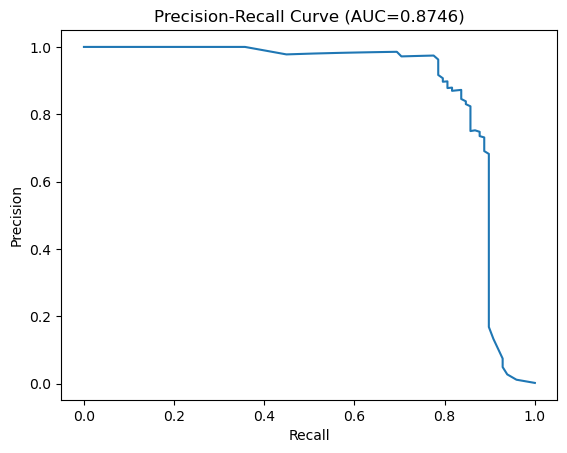

In [18]:
precision, recall, _ = precision_recall_curve(y_test, y_proba_rf)
pr_auc = auc(recall, precision)

plt.plot(recall, precision)
plt.title(f"Precision-Recall Curve (AUC={pr_auc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# --- 11. Threshold Tuning (Trade-off between fraud detection vs false alerts) ---

In [19]:
threshold = 0.3  # try lowering threshold

y_pred_custom = (y_proba_rf > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.89      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962

